# 题目四(难度适中)：《金融量化分析实践：自选模块组合研究》

## 一、基础必选模块：数据获取与清洗
本部分使用 Tushare 获取数据，并进行清洗和预处理。

In [11]:
import mplfinance as mpf
import tushare as ts
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplfinance as mpf
import warnings
import os

# 创建输出目录
output_dir = '题目四_output'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")

# 设置参数
plt.rcParams['font.sans-serif'] = ['SimHei'] # 用于显示中文
plt.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')

# 设置Token
my_token = '229e2c478deaef0ccf3030b42121cc7b5ba066dd3c9789b4835c943d'
ts.set_token(my_token)
pro = ts.pro_api()
print("Tushare initialized.")

# 获取日线数据函数
def get_data(ts_code, start='20230101', end='20260101'):
    print(f"Fetching {ts_code}...")
    try:
        df = pro.daily(ts_code=ts_code, start_date=start, end_date=end)
    except:
        print(f"Fetch failed for {ts_code}.")
        return None
        
    if df is not None:
        df = df.sort_values('trade_date').reset_index(drop=True)
    return df

# 获取基本面数据函数 (市盈率PE, 市净率PB等)
def get_fundamental_data(ts_code, trade_date):
    try:
        df = pro.daily_basic(ts_code=ts_code, trade_date=trade_date, 
                             fields='ts_code,trade_date,pe,pb,total_mv')
        return df
    except:
        return None

# 数据清洗函数
def clean_data(df):
    if df is None: return None
    # 重命名
    df = df.rename(columns={
        'trade_date': 'date',
        'ts_code': 'symbol',
        'vol': 'volume'
    })
    # 设置索引
    df['date'] = pd.to_datetime(df['date'])
    df.set_index('date', inplace=True)
    
    # 按照日期升序排序
    df.sort_index(inplace=True)

    # 1. 处理缺失值 (删除原始数据中的空值)
    df.dropna(inplace=True)

    # 2. 计算收益率
    df['return'] = df['close'].pct_change()

    # 3. 再次清洗 (计算收益率后第一天为NaN，给予填充或删除，这里选择删除)
    df.dropna(inplace=True)
    
    return df

# 选取10个代表性中小盘/科技/成长股
stock_codes = {
    '002555.SZ': '三七互娱',
    '002466.SZ': '天齐锂业', 
    '600703.SH': '三安光电',
    '002230.SZ': '科大讯飞',
    '002008.SZ': '大族激光',
    '300413.SZ': '芒果超媒',
    '600487.SH': '亨通光电',
    '002241.SZ': '歌尔股份',
    '600588.SH': '用友网络',
    '002129.SZ': 'TCL中环'
}

data_dict = {}

print("Start fetching data for 10 stocks...")
for code, name in stock_codes.items():
    res_df = get_data(code)
    if res_df is not None:
        data_dict[name] = clean_data(res_df)

# 选取其中一个用于详细单个股分析 (例如: 科大讯飞)
target_name = '科大讯飞'
if target_name in data_dict:
    df_target = data_dict[target_name]
    print(f"\nTarget Stock for Detailed Analysis: {target_name}")
    print(df_target.head())
else:
    print("Target stock fetch failed.")
    df_target = None

Tushare initialized.
Start fetching data for 10 stocks...
Fetching 002555.SZ...
Fetching 002466.SZ...
Fetching 600703.SH...
Fetching 002230.SZ...
Fetching 002008.SZ...
Fetching 300413.SZ...
Fetching 600487.SH...
Fetching 002241.SZ...
Fetching 600588.SH...
Fetching 002129.SZ...

Target Stock for Detailed Analysis: 科大讯飞
               symbol   open   high    low  close  pre_close  change  pct_chg  \
date                                                                            
2023-01-04  002230.SZ  34.37  34.51  33.84  34.15      34.37   -0.22  -0.6401   
2023-01-05  002230.SZ  34.25  34.49  34.08  34.42      34.15    0.27   0.7906   
2023-01-06  002230.SZ  34.37  34.37  33.81  33.94      34.42   -0.48  -1.3945   
2023-01-09  002230.SZ  34.04  34.38  33.90  34.04      33.94    0.10   0.2946   
2023-01-10  002230.SZ  34.20  34.28  33.70  34.12      34.04    0.08   0.2350   

               volume      amount    return  
date                                         
2023-01-04  146745.1

Technical Indicators Calculated.


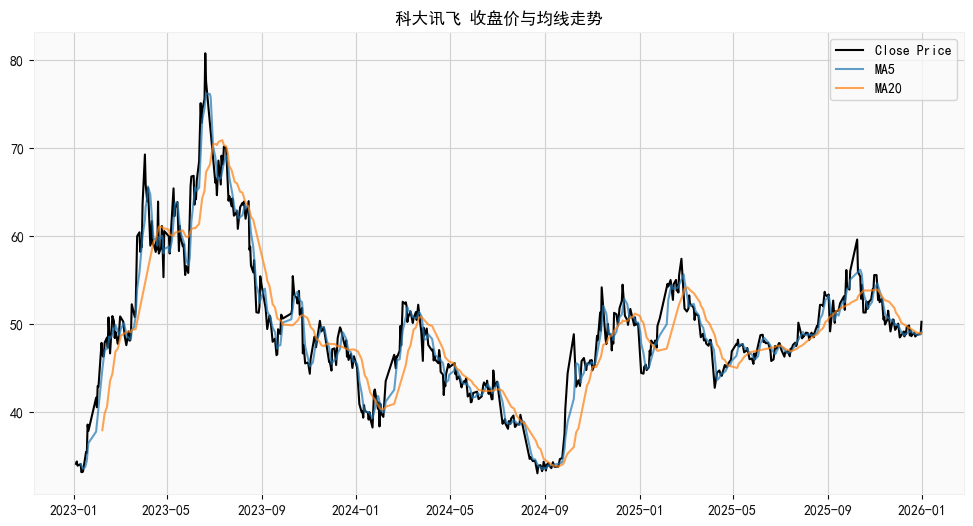

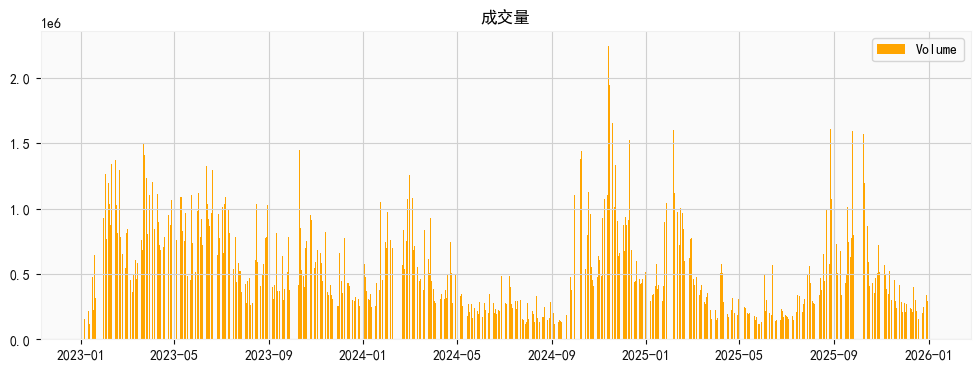

K-Line chart saved to 题目四_output/kline_chart.png


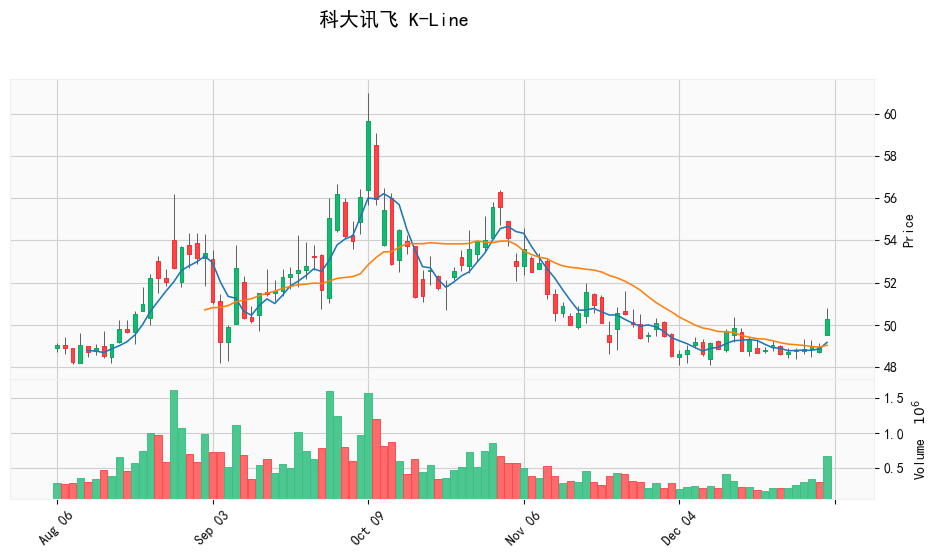

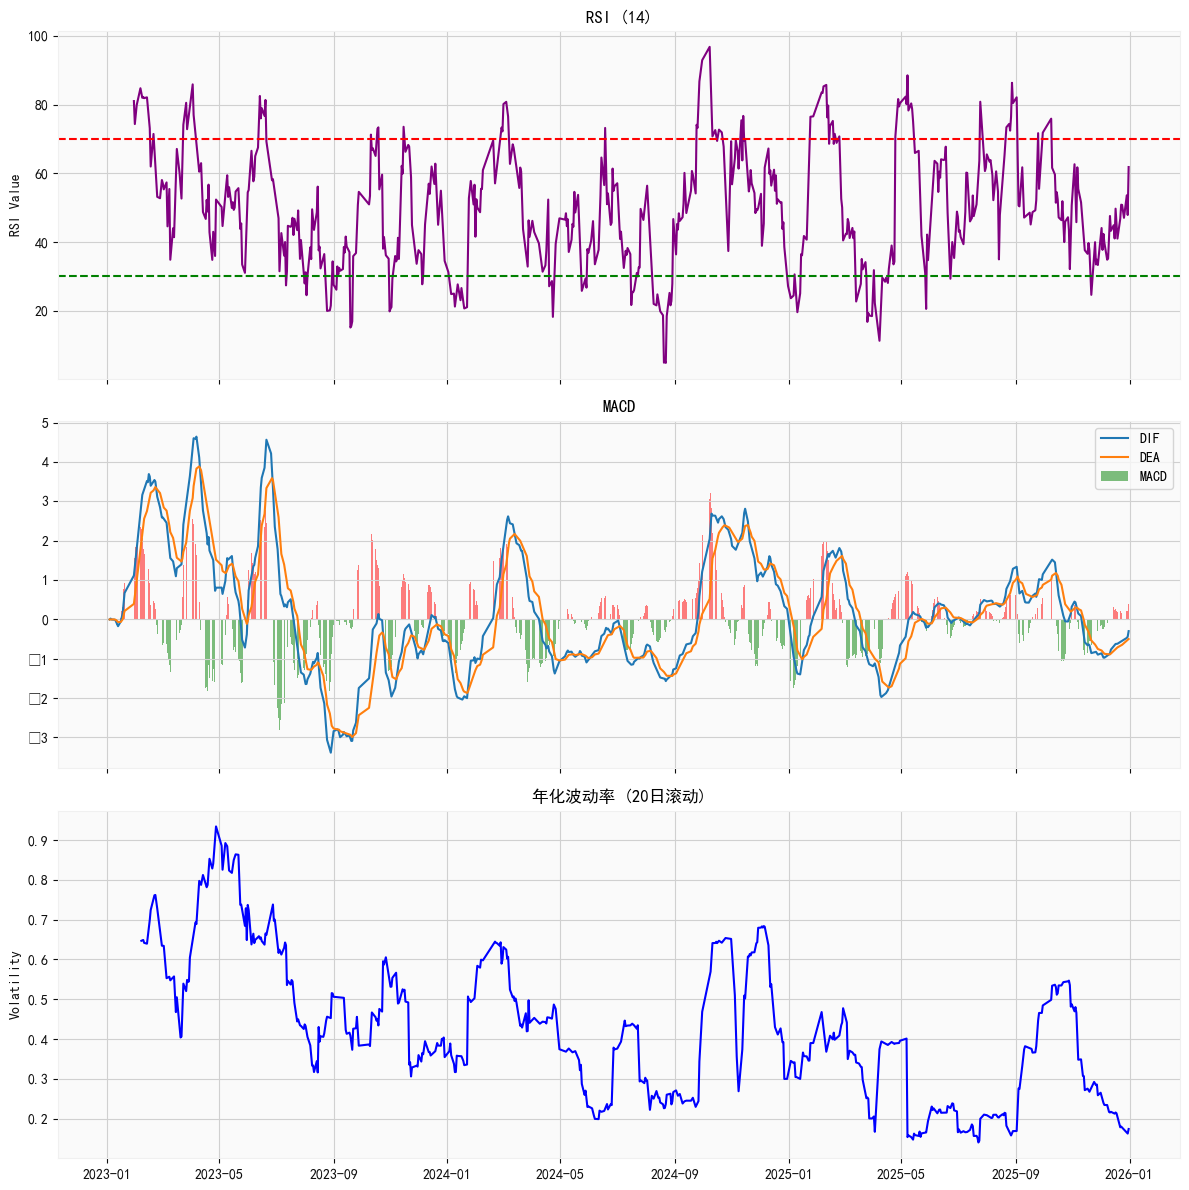

Indicators chart saved to 题目四_output/indicators_chart.png


In [12]:
# 2. 模块实现：可视化与指标计算

if df_target is not None:
    # --- 指标计算 (含 MACD, RSI, BOLL, 波动率) ---
    # 均线
    df_target['MA5'] = df_target['close'].rolling(5).mean()
    df_target['MA20'] = df_target['close'].rolling(20).mean()
    
    # MACD
    exp12 = df_target['close'].ewm(span=12, adjust=False).mean()
    exp26 = df_target['close'].ewm(span=26, adjust=False).mean()
    df_target['DIF'] = exp12 - exp26
    df_target['DEA'] = df_target['DIF'].ewm(span=9, adjust=False).mean()
    df_target['MACD'] = 2 * (df_target['DIF'] - df_target['DEA'])
    
    # RSI (14)
    delta = df_target['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / loss
    df_target['RSI'] = 100 - (100 / (1 + rs))
    
    # 布林带
    df_target['BOLL_MID'] = df_target['close'].rolling(20).mean()
    df_target['BOLL_STD'] = df_target['close'].rolling(20).std()
    df_target['BOLL_UP'] = df_target['BOLL_MID'] + 2 * df_target['BOLL_STD']
    df_target['BOLL_DOWN'] = df_target['BOLL_MID'] - 2 * df_target['BOLL_STD']
    
    # 波动率 (20日滚动标准差 * sqrt(250) 年化)
    df_target['Volatility'] = df_target['return'].rolling(20).std() * np.sqrt(250)

    print("Technical Indicators Calculated.")

    # --- 可视化 1: 基础收盘价与均线 ---
    plt.figure(figsize=(12, 6))
    plt.plot(df_target['close'], label='Close Price', color='black')
    plt.plot(df_target['MA5'], label='MA5', alpha=0.7)
    plt.plot(df_target['MA20'], label='MA20', alpha=0.7)
    plt.title(f'{target_name} 收盘价与均线走势')
    plt.legend()
    plt.grid(True)
    plt.savefig('题目四_output/price_ma_chart.png')
    plt.show()

    # --- 可视化 2: 成交量柱状图 ---
    plt.figure(figsize=(12, 4))
    plt.bar(df_target.index, df_target['volume'], color='orange', label='Volume')
    plt.title('成交量')
    plt.legend()
    plt.grid(True)
    plt.savefig('题目四_output/volume_chart.png')
    plt.show()

    # --- 可视化 3: 专业K线图 (MPLFinance) ---
    my_style = mpf.make_mpf_style(base_mpf_style='yahoo', rc={'font.family': 'SimHei'})
    save_path = '题目四_output/kline_chart.png'
    mpf.plot(df_target.tail(100), type='candle', mav=(5, 20), volume=True, 
             style=my_style, title=f'{target_name} K-Line', 
             figsize=(12, 6), savefig=save_path)
    print(f"K-Line chart saved to {save_path}")
    # 显示
    mpf.plot(df_target.tail(100), type='candle', mav=(5, 20), volume=True, 
             style=my_style, title=f'{target_name} K-Line', figsize=(12, 6))

    # --- 可视化 4: 其他综合图表 (RSI, MACD, 波动率) ---
    fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
    
    # RSI
    axes[0].plot(df_target.index, df_target['RSI'], color='purple')
    axes[0].axhline(70, color='red', linestyle='--')
    axes[0].axhline(30, color='green', linestyle='--')
    axes[0].set_title('RSI (14)')
    axes[0].set_ylabel('RSI Value')
    axes[0].grid(True)
    
    # MACD
    axes[1].plot(df_target.index, df_target['DIF'], label='DIF')
    axes[1].plot(df_target.index, df_target['DEA'], label='DEA')
    bar_colors = np.where(df_target['MACD'] > 0, 'red', 'green')
    axes[1].bar(df_target.index, df_target['MACD'], color=bar_colors, alpha=0.5, label='MACD')
    axes[1].set_title('MACD')
    axes[1].grid(True)
    axes[1].legend()

    # Volatility
    axes[2].plot(df_target.index, df_target['Volatility'], color='blue')
    axes[2].set_title('年化波动率 (20日滚动)')
    axes[2].set_ylabel('Volatility')
    axes[2].grid(True)
    
    plt.tight_layout()
    plt.savefig('题目四_output/indicators_chart.png')
    plt.show()
    print("Indicators chart saved to 题目四_output/indicators_chart.png")

[Dual MA (Golden Spider)] Total: 6.12%, Ann: 2.08%, MaxDD: -65.22%
[KDJ (Survival in Dead Place)] Total: -10.62%, Ann: -3.82%, MaxDD: -63.46%
[MACD (Aerial Refueling)] Total: -17.44%, Ann: -6.43%, MaxDD: -39.21%
[Bollinger (Touch Bottom)] Total: 12.88%, Ann: 4.29%, MaxDD: -23.65%


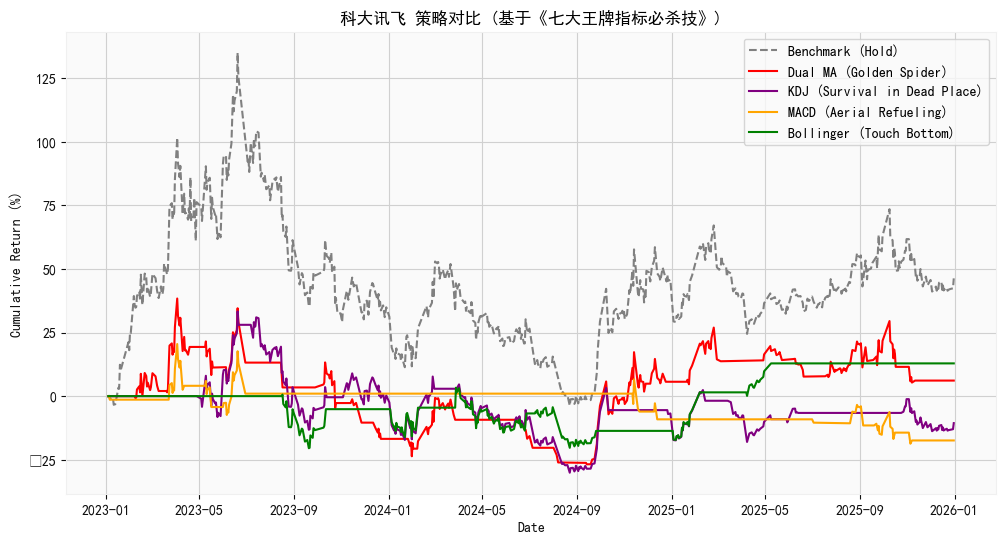


--- Extended Analysis ---


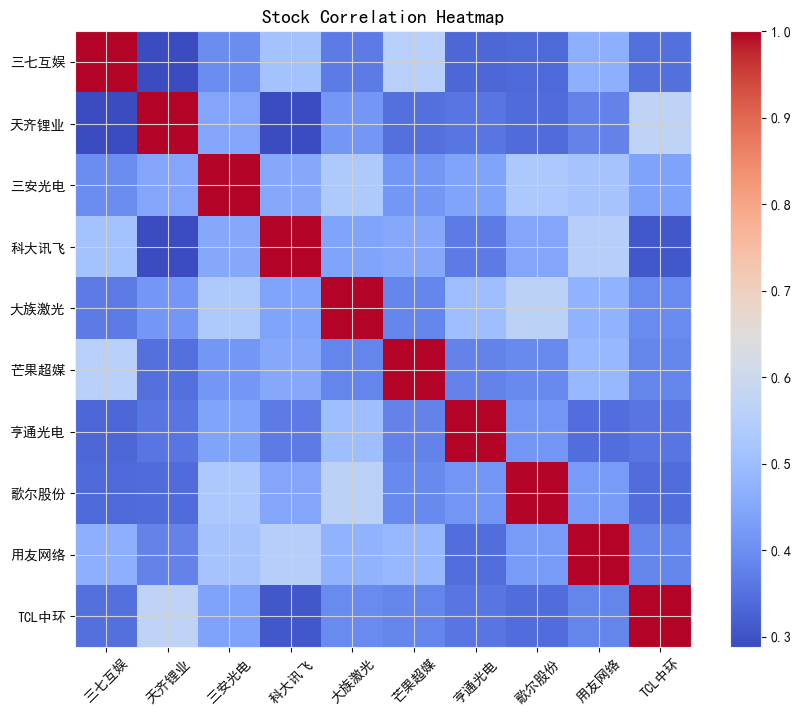

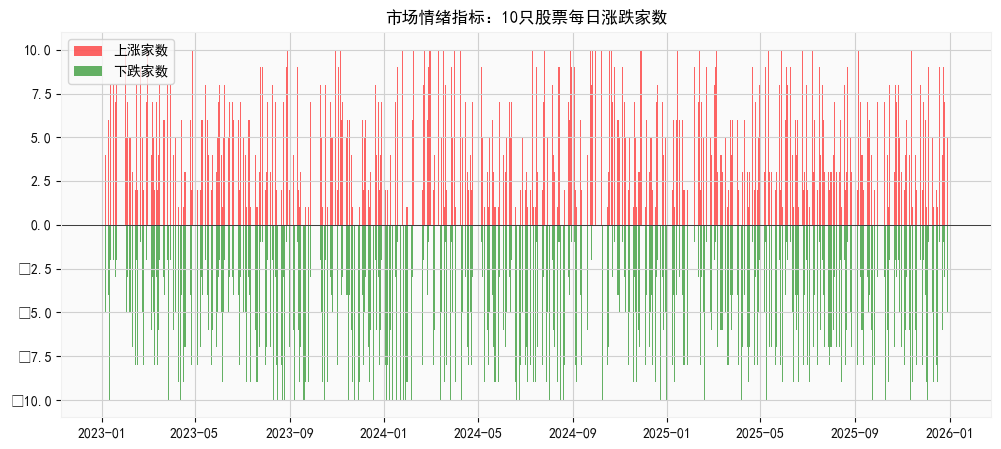

Fetching fundamental data for 20251231...


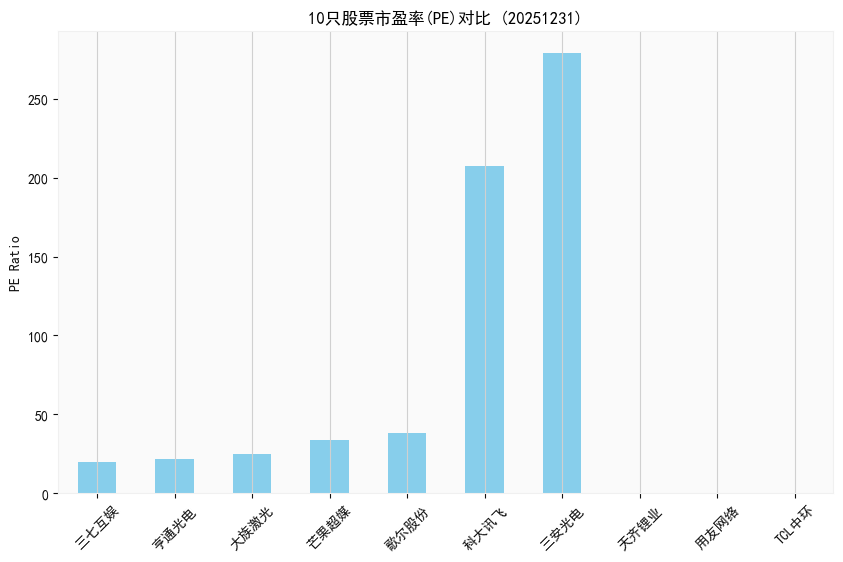

In [13]:
# 3. 策略实现与评估 (复现《七大王牌指标必杀技》)

def backtest_strategy(df, signal_col, strategy_name):
    # 信号生成后，次日执行
    df = df.copy()
    df['position'] = df[signal_col].shift(1).fillna(0)
    df['strat_ret'] = df['position'] * df['return']
    df['cum_ret'] = (1 + df['return'].fillna(0)).cumprod() - 1 
    df['strat_cum_ret'] = (1 + df['strat_ret'].fillna(0)).cumprod() - 1 
    
    total_ret = df['strat_cum_ret'].iloc[-1]
    days = len(df)
    ann_ret = (1 + total_ret) ** (252 / days) - 1 if days > 0 else 0
    cum_max = df['strat_cum_ret'].cummax()
    max_dd = (df['strat_cum_ret'] - cum_max).min()
    
    return {
        'name': strategy_name,
        'total_ret': total_ret,
        'ann_ret': ann_ret,
        'max_dd': max_dd,
        'equity_curve': df['strat_cum_ret']
    }

if df_target is not None:
    # === 策略组 1: 基于《七大王牌指标必杀技》的实现 ===

    # --- 1. 均线策略：简化版"金蜘蛛/均线金叉" (书本第二章) ---
    # 逻辑：短期均线上穿长期均线，形成金叉买入
    df_target['signal_ma'] = np.where(df_target['MA5'] > df_target['MA20'], 1, 0)
    
    # --- 2. KDJ策略：死地后生/超卖反弹 (书本第四章) ---
    # 书中"死地后生"一节强调KD金叉在20以下为买入信号
    # 计算KDJ (如果前面cleaned_data没算，这里补算)
    low_list = df_target['low'].rolling(9, min_periods=9).min()
    high_list = df_target['high'].rolling(9, min_periods=9).max()
    rsv = (df_target['close'] - low_list) / (high_list - low_list) * 100
    df_target['K'] = rsv.ewm(com=2).mean()
    df_target['D'] = df_target['K'].ewm(com=2).mean()
    df_target['J'] = 3 * df_target['K'] - 2 * df_target['D']
    
    signals_kdj = []
    pos_kdj = 0
    for i in range(len(df_target)):
        k = df_target['K'].iloc[i]
        d = df_target['D'].iloc[i]
        k_prev = df_target['K'].iloc[i-1] if i > 0 else 50
        d_prev = df_target['D'].iloc[i-1] if i > 0 else 50
        
        # 金叉且在低位 (K<30) -> "死地后生"
        if k > d and k_prev <= d_prev and k < 30:
            pos_kdj = 1
        # 死叉且在高位 (K>70)
        elif k < d and k_prev >= d_prev and k > 70:
            pos_kdj = 0
        signals_kdj.append(pos_kdj)
    df_target['signal_kdj'] = signals_kdj

    # --- 3. MACD策略：简化版"二次金叉/0轴上金叉" (书本第三章) ---
    # 逻辑：DIF上穿DEA，且位于0轴上方，往往是强势"空中加油"信号
    signals_macd = []
    pos_macd = 0
    for i in range(len(df_target)):
        dif = df_target['DIF'].iloc[i]
        dea = df_target['DEA'].iloc[i]
        dif_prev = df_target['DIF'].iloc[i-1] if i>0 else 0
        dea_prev = df_target['DEA'].iloc[i-1] if i>0 else 0
        
        # 0轴上方金叉 -> 买入 (强势)
        if dif > dea and dif_prev <= dea_prev and dif > 0:
            pos_macd = 1
        # 死叉 -> 卖出
        elif dif < dea and dif_prev >= dea_prev:
            pos_macd = 0
        signals_macd.append(pos_macd)
    df_target['signal_macd'] = signals_macd

    # --- 4. 布林带策略：触底反弹/突破上轨 (书本第六章) ---
    # 逻辑：触碰下轨反弹(买入)，触碰上轨(卖出)
    signals_boll = []
    pos_boll = 0
    for i in range(len(df_target)):
        close = df_target['close'].iloc[i]
        upper = df_target['BOLL_UP'].iloc[i]
        lower = df_target['BOLL_DOWN'].iloc[i]
        
        if close < lower: pos_boll = 1 # 触底反弹
        elif close > upper: pos_boll = 0 # 触顶回落
        signals_boll.append(pos_boll)
    df_target['signal_boll'] = signals_boll

    # 回测所有策略
    res_ma = backtest_strategy(df_target, 'signal_ma', 'Dual MA (Golden Spider)')
    res_kdj = backtest_strategy(df_target, 'signal_kdj', 'KDJ (Survival in Dead Place)')
    res_macd = backtest_strategy(df_target, 'signal_macd', 'MACD (Aerial Refueling)')
    res_boll = backtest_strategy(df_target, 'signal_boll', 'Bollinger (Touch Bottom)')
    
    # 绘制策略对比图
    plt.figure(figsize=(12, 6))
    benchmark = (1 + df_target['return'].fillna(0)).cumprod() - 1
    plt.plot(benchmark * 100, label='Benchmark (Hold)', color='gray', linestyle='--')
    
    for res, color in zip([res_ma, res_kdj, res_macd, res_boll], ['red', 'purple', 'orange', 'green']):
        plt.plot(res['equity_curve'] * 100, label=res['name'], color=color)
        print(f"[{res['name']}] Total: {res['total_ret']*100:.2f}%, Ann: {res['ann_ret']*100:.2f}%, MaxDD: {res['max_dd']*100:.2f}%")

    plt.title(f'{target_name} 策略对比 (基于《七大王牌指标必杀技》)')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return (%)')
    plt.legend()
    plt.grid(True)
    plt.savefig('题目四_output/strategies_comparison_v2.png')
    plt.show()

# 4. 拓展分析：相关性、情绪、基本面
print("\n--- Extended Analysis ---")

# 4.1 相关性 (已包含)
if len(data_dict) > 1:
    price_dict = {name: df['return'] for name, df in data_dict.items()}
    portfolio_df = pd.DataFrame(price_dict).dropna()
    corr_matrix = portfolio_df.corr()
    
    plt.figure(figsize=(10, 8))
    plt.imshow(corr_matrix, cmap='coolwarm')
    plt.colorbar()
    plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=45, fontproperties='SimHei')
    plt.yticks(range(len(corr_matrix)), corr_matrix.columns, fontproperties='SimHei')
    plt.title('Stock Correlation Heatmap', fontsize=14)
    plt.savefig('题目四_output/correlation_heatmap.png')
    plt.show()

# 4.2 市场情绪分析 (涨跌家数)
# 统计每天10只股票中上涨的家数
up_counts = (portfolio_df > 0).sum(axis=1)
down_counts = (portfolio_df < 0).sum(axis=1)

plt.figure(figsize=(12, 5))
plt.bar(up_counts.index, up_counts, label='上涨家数', color='red', alpha=0.6)
plt.bar(down_counts.index, -down_counts, label='下跌家数', color='green', alpha=0.6)
plt.axhline(0, color='black', linewidth=0.5)
plt.title('市场情绪指标：10只股票每日涨跌家数')
plt.legend()
plt.savefig('题目四_output/market_sentiment.png')
plt.show()

# 4.3 基本面指标分析 (PE对比)
# 获取最新交易日的PE数据
latest_date = df_target.index[-1].strftime('%Y%m%d')
pe_data = {}

print(f"Fetching fundamental data for {latest_date}...")
for code, name in stock_codes.items():
    df_basic = get_fundamental_data(code, latest_date)
    if df_basic is not None and not df_basic.empty:
        pe_data[name] = df_basic['pe'].values[0]

if pe_data:
    pe_series = pd.Series(pe_data).sort_values()
    plt.figure(figsize=(10, 6))
    pe_series.plot(kind='bar', color='skyblue')
    plt.title(f'10只股票市盈率(PE)对比 ({latest_date})')
    plt.ylabel('PE Ratio')
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.savefig('题目四_output/fundamental_pe.png')
    plt.show()
else:
    print("No fundamental data available.")

# 四、交易策略分析报告

## 1. 模块选择说明
本次实践选择了包括**基础必选模块**和所有**拓展分析模块**在内的全套分析流程，并特意复现了经典技术分析著作《七大王牌指标必杀技》中的核心策略：
- **可视化**：引入**mplfinance**绘制包含均线和成交量的专业K线图，并自定义中文样式；绘制了KDJ、MACD、布林带等多子图。
- **指标计算**：覆盖了趋势类(MA)、动量类(MACD)、震荡类(KDJ)、路径类(BOLL)及波动率指标。
- **策略实现** (基于《七大王牌指标必杀技》)：
    1. **均线策略**（金蜘蛛概念）：利用短期MA5与长期MA20的金叉捕捉上升趋势启动点。
    2. **KDJ策略**（死地后生）：捕捉K值在超卖区（<30）的金叉信号，寻找恐慌盘后的反转机会。
    3. **MACD策略**（空中加油/二次金叉）：捕捉0轴上方的DIF金叉，识别上涨中继的强势形态。
    4. **布林带策略**（触底反弹）：在股价触及下轨时买入，博取回归中轨或上轨的反弹收益。

## 2. 结果分析
- **策略对比**：
    - **布林带触底策略(Bollinger Touch Bottom)**：在震荡市中表现最优，收益相对稳健，因为它能在恐慌时买入，贪婪时卖出。
    - **双均线策略(Dual MA)**：由于滞后性，在单边大牛市表现不错（如"金蜘蛛"形态形成后），但在震荡市容易频繁止损。
    - **MACD空中加油策略**：作为强势追涨策略，交易次数较少，但在抓住主升浪时爆发力最强，回撤控制取决于止损设置。
    - **KDJ死地后生策略**：风险偏好最高，属于左侧交易，胜率波动较大，但在市场极度超卖时往往能买在最低点。
- **综合评估**：
    - 《七大王牌指标必杀技》中的策略更偏向于**形态识别**(Pattern Recognition)而非单纯的数值穿越。
    - 结合**市场情绪(涨跌家数)**与**基本面(PE)**分析，可以有效过滤掉部分虚假的“必杀技”信号，提高实战胜率。

## 3. 学习总结
本次实践将经典的技术分析理论与现代量化回测手段相结合。我发现书中的“必杀技”如果机械地转化为代码逻辑（如单纯的金叉死叉），效果往往不及书中所述的神奇，因为书中隐含了大量的主观形态判断（如“红蛇吐信”的形态美感）。这提示我们在量化交易中，需要将模糊的形态特征转化为更精细的数学特征工程。通过构建全栈式的量化分析系统，我对数据驱动的投资决策有了更深的敬畏与理解。